In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='bmi', ylabel='charges'>

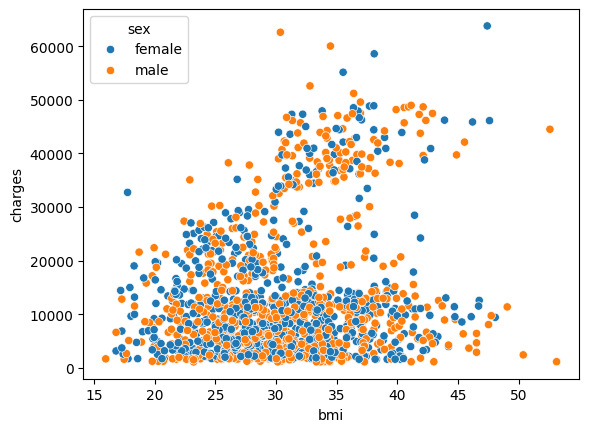

In [5]:
sns.scatterplot(x= df["bmi"], y=df["charges"], hue=df["sex"])

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [7]:
X = df.drop(columns=["charges"])
Y = df["charges"]

In [8]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [9]:
Y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=11)

In [12]:
X_test.head()

,age,sex,bmi,children,smoker,region
1313,19,female,34.700,2,yes,southwest
1254,34,female,27.720,0,no,southeast
372,42,female,33.155,1,no,northeast
937,39,female,24.225,5,no,northwest
484,48,male,34.300,3,no,southwest


In [13]:
#X ["sex"] = X["sex"].map({"female": 1, "male": 0})
#X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})

In [14]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
X_test.head()

,age,sex,bmi,children,smoker,region
1313,19,female,34.700,2,yes,southwest
1254,34,female,27.720,0,no,southeast
372,42,female,33.155,1,no,northeast
937,39,female,24.225,5,no,northwest
484,48,male,34.300,3,no,southwest


In [16]:
# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Initialize the OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
encoded_data = ohe.fit_transform(X_train[categorical_cols])

# Get the names of the encoded features
encoded_features = ohe.get_feature_names_out(categorical_cols)

# Create a DataFrame with the new encoded features
encoded_df = pd.DataFrame(encoded_data, columns=encoded_features, index=X_train.index)

# Drop the original categorical columns from the original DataFrame
df_numeric = X_train.drop(columns=categorical_cols)

# Concatenate the numeric and encoded DataFrames
df_final = pd.concat([df_numeric, encoded_df], axis=1)

C:\Users\Mazhar Iqbal\AppData\Local\Temp\ipykernel_10244\900258037.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns


In [17]:
encoded_features

array(['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast',
       'region_southwest'], dtype=object)

In [18]:
df_final.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
316,50,32.205,0,1.0,0.0,1.0,0.0,0.0
340,24,27.600,0,0.0,0.0,0.0,0.0,1.0
151,48,29.700,0,1.0,0.0,0.0,1.0,0.0
1282,18,21.660,0,0.0,1.0,0.0,0.0,0.0
557,34,34.210,0,1.0,0.0,0.0,1.0,0.0


In [19]:
X_train.head()

,age,sex,bmi,children,smoker,region
316,50,male,32.205,0,no,northwest
340,24,female,27.600,0,no,southwest
151,48,male,29.700,0,no,southeast
1282,18,female,21.660,0,yes,northeast
557,34,male,34.210,0,no,southeast


In [20]:
Y_train.head()

316      8835.26495
340     18955.22017
151      7789.63500
1282    14283.45940
557      3935.17990
Name: charges, dtype: float64

In [21]:
df.shape

(1338, 7)

In [22]:
print(x.shape)
print(Y_train.shape)

NameError: name 'x' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df_final, Y_train) 
model.coef_

array([  264.57591084,   343.7571095 ,   541.36367171,  -393.34488293,
       23556.99297449,  -461.77207723, -1048.89594502, -1066.11107739])

In [ ]:
# Identify categorical columns
categorical_cols = X_test.select_dtypes(include=['object']).columns

# Initialize the OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical columns
X_test_encoded_data = ohe.fit_transform(X_test[categorical_cols])

# Get the names of the encoded features
X_test_encoded_features = ohe.get_feature_names_out(categorical_cols)

# Create a DataFrame with the new encoded features
X_test_encoded_df = pd.DataFrame(X_test_encoded_data, columns=X_test_encoded_features, index=X_test.index)

# Drop the original categorical columns from the original DataFrame
X_test_df_numeric = X_test.drop(columns=categorical_cols)

# Concatenate the numeric and encoded DataFrames
X_test_df_final = pd.concat([X_test_df_numeric, X_test_encoded_df], axis=1)

C:\Users\Mazhar Iqbal\AppData\Local\Temp\ipykernel_12384\134482843.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_test.select_dtypes(include=['object']).columns


In [ ]:
y_pred = model.predict(X_test_df_final)

In [ ]:
y_pred

array([28324.6937405 ,  5271.40259325, 10846.58938687,  8686.79327608,
       12450.9181254 , 10967.61928289,  7851.21864742, 15704.82478742,
       11727.29362659, 32984.27106292,  6671.6646637 , 15515.99250414,
       10982.94447641,  2209.93150928,  6192.23737667, 35139.70176504,
        3759.89760582,   100.63204344,  8206.62956647, 13088.80590719,
       10670.10481527,  3045.35228561,  2951.45334163,  4189.00867532,
        4296.3928236 , 15235.61211624,  5164.34033153,  8156.04358891,
       26724.11719451,  7842.75636536, 33350.45795514, 30702.8662383 ,
        2286.02632728,  -454.74285254, 31734.4213872 , 14611.18370375,
        5684.3484833 , 26546.99293214, 11391.35565209,  8834.94567963,
        6603.49537643, 13248.21765982, 27282.51486936,   621.68107179,
        9094.22413406, 11202.48498856, 30735.65359573,  2838.01349549,
        9040.31253333, 26497.31574989, 13243.96124201, 29204.69881051,
       15241.04570786, 35326.70447063, 12152.34437332,  2741.61716445,
      

In [ ]:
Y_test

1313    36397.576000
1254     4415.158800
372      7639.417450
937      8965.795750
484      9563.029000
            ...     
427      7323.734819
1153     5630.457850
973      1759.338000
608      4435.094200
775     10560.491700
Name: charges, Length: 268, dtype: float64

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, y_pred)
print("r-squared:", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2) * (n-1) / (n-p-1))
print("adjusted r^2:", adjusted_r2)

r-squared: 0.7996633930323263
adjusted r^2: 0.7950579537916901


# One Hot Encoding

In [ ]:
X = df.drop(columns=["charges"])

In [ ]:
x = pd.get_dummies(X, columns=["sex", "region", "smoker"], drop_first=True, dtype= int)
x.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
0,19,27.900,0,0,0,0,1,1
1,18,33.770,1,1,0,1,0,0
2,28,33.000,3,1,0,1,0,0
3,33,22.705,0,1,1,0,0,0
4,32,28.880,0,1,1,0,0,0


- First Split Data then do everything else including preprocessing
- In One hot Encoding drop the first coloumns

# Feature Engeneering

- Encoding Categorical Values
   - One Hot Encoding
- Create useful Derived Features
   - Example: Underweight / Overweight
- Interaction Features
   - Example: Age + Smoker | bmi + Smoker
- Scaling Numeric Features
   - Normalization
   - Standardization
- Feature Selection
   - Eliminating useless features

# Derived Feature: Weight Category

In [ ]:
x['Weight Category'] = x['bmi'].apply(lambda bmi: 'Underweight' if bmi < 18.5 else ('Overweight' if 25 <= bmi <= 29.9 else 'Fit'))
x.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes,Weight Category
0,19,27.900,0,0,0,0,1,1,Overweight
1,18,33.770,1,1,0,1,0,0,Fit
2,28,33.000,3,1,0,1,0,0,Fit
3,33,22.705,0,1,1,0,0,0,Fit
4,32,28.880,0,1,1,0,0,0,Overweight


In [ ]:
df["bmi"].value_counts()

bmi
32.30    13
28.31     9
28.88     8
34.10     8
30.80     8
         ..
53.13     1
39.71     1
32.87     1
44.70     1
30.97     1
Name: count, Length: 548, dtype: int64

In [ ]:
x = pd.get_dummies(x, columns=["Weight Category"], drop_first=True, dtype= int)
x.head()


,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes,Weight Category_Overweight,Weight Category_Underweight
0,19,27.900,0,0,0,0,1,1,1,0
1,18,33.770,1,1,0,1,0,0,0,0
2,28,33.000,3,1,0,1,0,0,0,0
3,33,22.705,0,1,1,0,0,0,0,0
4,32,28.880,0,1,1,0,0,0,1,0


In [ ]:
x['Age Category'] = x['age'].apply(lambda age: 'Young' if age < 60 else 'Old')
x.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes,Weight Category_Overweight,Weight Category_Underweight,Age Category
0,19,27.900,0,0,0,0,1,1,1,0,Young
1,18,33.770,1,1,0,1,0,0,0,0,Young
2,28,33.000,3,1,0,1,0,0,0,0,Young
3,33,22.705,0,1,1,0,0,0,0,0,Young
4,32,28.880,0,1,1,0,0,0,1,0,Young


In [ ]:
x['Age Category'].value_counts()

Age Category
Young    1224
Old       114
Name: count, dtype: int64

In [ ]:
x = pd.get_dummies(x, columns=["Age Category"], drop_first=True, dtype= int)
x.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes,Weight Category_Overweight,Weight Category_Underweight,Age Category_Young
0,19,27.900,0,0,0,0,1,1,1,0,1
1,18,33.770,1,1,0,1,0,0,0,0,1
2,28,33.000,3,1,0,1,0,0,0,0,1
3,33,22.705,0,1,1,0,0,0,0,0,1
4,32,28.880,0,1,1,0,0,0,1,0,1


In [ ]:
x['Age Category_Old'] = x['Age Category_Young'].map({1: 0, 0: 1})
x.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes,Weight Category_Overweight,Weight Category_Underweight,Age Category_Young,Age Category_Old
0,19,27.900,0,0,0,0,1,1,1,0,1,0
1,18,33.770,1,1,0,1,0,0,0,0,1,0
2,28,33.000,3,1,0,1,0,0,0,0,1,0
3,33,22.705,0,1,1,0,0,0,0,0,1,0
4,32,28.880,0,1,1,0,0,0,1,0,1,0


In [ ]:
x.drop(columns="Age Category_Young", inplace= True)
x.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes,Weight Category_Overweight,Weight Category_Underweight,Age Category_Old
0,19,27.900,0,0,0,0,1,1,1,0,0
1,18,33.770,1,1,0,1,0,0,0,0,0
2,28,33.000,3,1,0,1,0,0,0,0,0
3,33,22.705,0,1,1,0,0,0,0,0,0
4,32,28.880,0,1,1,0,0,0,1,0,0


# Interaction Feature: Special Metric

In [ ]:
x['Special Metric'] = x['Age Category_Old'] + x["Weight Category_Underweight"] + x["Weight Category_Overweight"] + x["smoker_yes"]
x.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes,Weight Category_Overweight,Weight Category_Underweight,Age Category_Old,Special Metric
0,19,27.900,0,0,0,0,1,1,1,0,0,2
1,18,33.770,1,1,0,1,0,0,0,0,0,0
2,28,33.000,3,1,0,1,0,0,0,0,0,0
3,33,22.705,0,1,1,0,0,0,0,0,0,0
4,32,28.880,0,1,1,0,0,0,1,0,0,1


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, Y_train) 
model.coef_

NameError: name 'x' is not defined

Creating a def Function

In [ ]:
def Feature_Engeneering(DataFrame) :
    x = pd.get_dummies(DataFrame, columns=["sex", "region", "smoker"], drop_first=True, dtype= int)
    x['Weight Category'] = x['bmi'].apply(lambda bmi: 'Underweight' if bmi < 18.5 else ('Overweight' if 25 <= bmi <= 29.9 else 'Fit'))
    x = pd.get_dummies(x, columns=["Weight Category"], drop_first=True, dtype= int)
    x['Age Category'] = x['age'].apply(lambda age: 'Young' if age < 60 else 'Old')
    x = pd.get_dummies(x, columns=["Age Category"], drop_first=True, dtype= int)
    x['Age Category_Old'] = x['Age Category_Young'].map({1: 0, 0: 1})
    x.drop(columns="Age Category_Young", inplace= True)
    x['Special Metric'] = x['Age Category_Old'] + x["Weight Category_Underweight"] + x["Weight Category_Overweight"] + x["smoker_yes"]
    return x



In [ ]:
X_train =  Feature_Engeneering(X_train)

In [ ]:
X_train.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes,Weight Category_Overweight,Weight Category_Underweight,Age Category_Old,Special Metric
316,50,32.205,0,1,1,0,0,0,0,0,0,0
340,24,27.600,0,0,0,0,1,0,1,0,0,1
151,48,29.700,0,1,0,1,0,0,1,0,0,1
1282,18,21.660,0,0,0,0,0,1,0,0,0,1
557,34,34.210,0,1,0,1,0,0,0,0,0,0


In [ ]:
X_test = Feature_Engeneering(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)
model.coef_

array([  234.15849868,   302.60852124,   452.23811058,  -375.32658593,
        -375.36931581, -1046.95080626, -1147.55517757, 18805.00188588,
       -5523.55778993, -5596.45995122, -3310.04502744,  4374.93911729])

In [ ]:
Y_predict = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
r2 = r2_score(Y_test, Y_predict)
print("r-squared:", r2)

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2) * (n-1) / (n-p-1))
print("adjusted r^2:", adjusted_r2)

r-squared: 0.7439988341514384
adjusted r^2: 0.7319042908830025


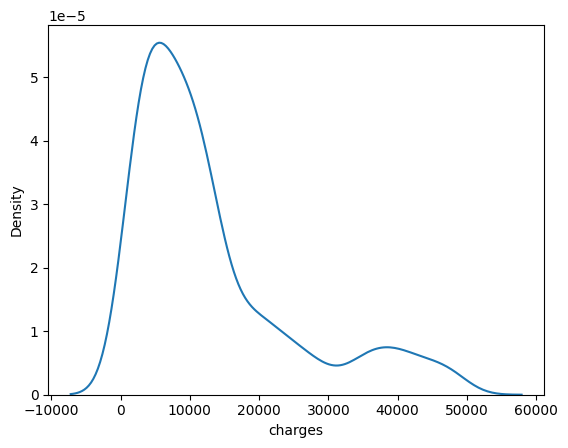

In [ ]:
sns.kdeplot(x='charges', data=df)
plt.show()

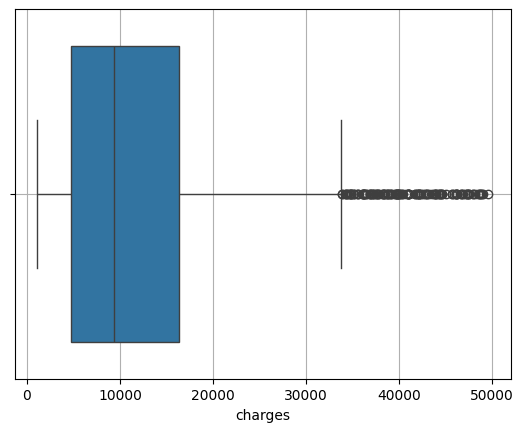

In [ ]:
sns.boxplot(x='charges', data=df)
plt.grid(True)
plt.show()

In [ ]:
df['charges'].apply(lambda charges: 'Underweight' if bmi < 18.5 else ('Overweight' if 25 <= bmi <= 29.9 else 'Fit'))


In [ ]:
df[df['charges'] >= 51000]

,age,sex,bmi,children,smoker,region,charges


In [ ]:
df.shape

(1331, 7)

In [ ]:
df = df[df['charges'] <= 51000]